# finance_db: use-case queries

Runs the conceptual-model use cases against the five-table fixture in this folder, to show they work end to end. Tables and provenance: `README.md`. Concepts: `knowledge-base/topics/data-sources/cl-climate-finance.md`.

In [1]:
import pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_colwidth",46)
funders=pd.read_csv("funders.csv"); opportunities=pd.read_csv("opportunities.csv")
projects=pd.read_csv("projects.csv"); actions=pd.read_csv("actions.csv")
project_funding=pd.read_csv("project_funding.csv")
{n:len(d) for n,d in [("funders",funders),("opportunities",opportunities),("projects",projects),("project_funding",project_funding),("actions",actions)]}

{'funders': 18,
 'opportunities': 100,
 'projects': 11310,
 'project_funding': 11322,
 'actions': 102}

## Use case 1 — benchmark an action on timeline and cost

The benchmark is rolled up from the action's example projects, not typed in. Each figure carries its sample size (`*_n`) so its reliability is visible.

In [2]:
bench=actions[["action_id","action_name","sector","match_confidence","bench_n_projects",
        "bench_duration_median_months","bench_duration_n","bench_cost_median_MMCLP","bench_cost_n"]]
# trust benchmarks only where match_confidence == "strong"
bench[bench.match_confidence=="strong"].sort_values("bench_n_projects",ascending=False)

,action_id,action_name,sector,match_confidence,bench_n_projects,bench_duration_median_months,bench_duration_n,bench_cost_median_MMCLP,bench_cost_n
91,ipcc_0105,Promote active mobility through road space...,transportation,strong,210,NaN,0,296.4,152
77,icare_0040,Deploy energy-efficient and solar-powered ...,stationary_energy,strong,131,NaN,0,89.6,115
53,icare_0012,Expand solar energy generation on municipa...,stationary_energy,strong,94,16.0,6,193.1,76
95,c40_0036,Upgrade Landfills to Engineered Sanitary L...,waste,strong,61,18.0,1,420.2,61
6,c40_0042,Expand urban and peri-urban green spaces,afolu,strong,40,19.0,2,150.2,40
82,icare_0137,Replace Inefficient Lighting with LED Tech...,stationary_energy,strong,30,NaN,0,143.4,24
0,ipcc_0053,"Implement afforestation, reforestation, an...",afolu,strong,24,30.0,16,402.9,24
2,ipcc_0068,Pilot Bioenergy with Carbon Capture in Par...,afolu,strong,14,36.0,9,386.9,13
55,icare_0015,Promote Mini and Micro-Hydropower and Biom...,stationary_energy,strong,6,28.0,2,384.8,4
54,icare_0026,Implement time-of-use electricity tariffs ...,stationary_energy,strong,5,24.0,5,1060.7,5


In [3]:
# worked example: size a candidate action from its benchmark
a=actions.sort_values("bench_duration_n",ascending=False).iloc[0]
print(f"Action: {a.action_name} ({a.sector})")
print(f"  typical timeline : {a.bench_duration_median_months:.0f} months   (median of {a.bench_duration_n} projects)")
print(f"  typical cost     : {a.bench_cost_median_MMCLP:,.0f} M CLP        (median of {a.bench_cost_n} projects)")

Action: Support cooperatives of voluntary waste collectors to aggregate into small enterprises and expand into organics management (waste)
  typical timeline : 24 months   (median of 20 projects)
  typical cost     : 380 M CLP        (median of 27 projects)


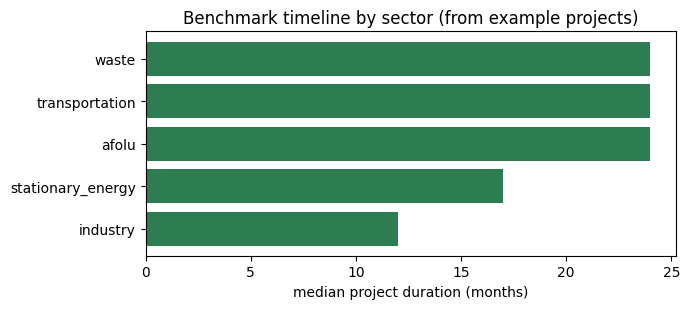

In [4]:
# median timeline by sector (inline)
s=actions.groupby("sector")["bench_duration_median_months"].median().sort_values()
fig,ax=plt.subplots(figsize=(7,3.2))
ax.barh(s.index,s.values,color="#2e7d52")
ax.set_xlabel("median project duration (months)"); ax.set_title("Benchmark timeline by sector (from example projects)")
fig.tight_layout(); plt.show()

## Use case 2 — trace an action to what got built and how it was paid for

Join projects to the action they instance, and read each project's stage, verdict, cost, duration, and the financing attached.

In [5]:
aid=actions.sort_values("bench_n_projects",ascending=False).iloc[0]["action_id"]
print("action_id:",aid,"—",actions.set_index("action_id").loc[aid,"action_name"])
projects[projects.action_id==aid][["project_id","lifecycle_stage","evaluation_verdict",
        "cost_total","amount_committed","amount_paid","duration_months","n_funding_sources"]].head(8)

action_id: ipcc_0105 — Promote active mobility through road space reallocation


,project_id,lifecycle_stage,evaluation_verdict,cost_total,amount_committed,amount_paid,duration_months,n_funding_sources
0,30044764-0,EJECUCION,FI,80.0,80.0,NaN,NaN,1
8,40041764-0,PERFIL,OT,84.4,84.4,NaN,NaN,1
10,40047226-0,DISEÑO,FI,8369.8,8369.8,NaN,NaN,1
13,30308475-0,DISEÑO,RS,41.9,41.9,NaN,NaN,1
22,40042113-0,EJECUCION,RS,297.1,297.1,NaN,NaN,1
23,40041953-0,PERFIL,OT,184.2,184.2,NaN,NaN,1
24,40039684-0,DISEÑO,RS,72.9,72.9,NaN,NaN,1
30,40040584-0,PERFIL,NaN,136.1,136.1,NaN,NaN,1


In [6]:
aid=actions.sort_values("bench_n_projects",ascending=False).iloc[0]["action_id"]
print("action_id:",aid,"—",actions.set_index("action_id").loc[aid,"action_name"])
projects[projects.action_id==aid][["project_id","lifecycle_stage","evaluation_verdict",
        "cost_total","amount_committed","amount_paid","duration_months","n_funding_sources"]].head(8)

action_id: ipcc_0105 — Promote active mobility through road space reallocation


,project_id,lifecycle_stage,evaluation_verdict,cost_total,amount_committed,amount_paid,duration_months,n_funding_sources
0,30044764-0,EJECUCION,FI,80.0,80.0,NaN,NaN,1
8,40041764-0,PERFIL,OT,84.4,84.4,NaN,NaN,1
10,40047226-0,DISEÑO,FI,8369.8,8369.8,NaN,NaN,1
13,30308475-0,DISEÑO,RS,41.9,41.9,NaN,NaN,1
22,40042113-0,EJECUCION,RS,297.1,297.1,NaN,NaN,1
23,40041953-0,PERFIL,OT,184.2,184.2,NaN,NaN,1
24,40039684-0,DISEÑO,RS,72.9,72.9,NaN,NaN,1
30,40040584-0,PERFIL,NaN,136.1,136.1,NaN,NaN,1


## Use case 3 — the supply side for a sector

List the funding opportunities a city could pursue or facilitate for a sector, with how to reach them.

In [7]:
sector="stationary_energy"
opportunities[opportunities.gpc_sectors.str.contains(sector,na=False)][
    ["opportunity_name","funder_name","instrument","eligible_actor","access_pathway","status","source_dataset"]]

,opportunity_name,funder_name,instrument,eligible_actor,access_pathway,status,source_dataset
0,FPA 2026 - Proyectos Sustentables Ciudadanos,Ministerio del Medio Ambiente (MMA),grant,community/citizen org,direct application (via fondos.gob.cl),closed,cl-mma/cl-mma-fondos
1,FPA 2026 - Proyectos Sustentables en Estab...,Ministerio del Medio Ambiente (MMA),grant,community/citizen org,direct application (via fondos.gob.cl),closed,cl-mma/cl-mma-fondos
2,FPA 2026 - Proyectos Sustentables para Pue...,Ministerio del Medio Ambiente (MMA),grant,indigenous community,direct application (via fondos.gob.cl),closed,cl-mma/cl-mma-fondos
54,Comuna Energética,Ministerio de Energía / Agencia de Sosteni...,technical_assistance + grant (co-financing),municipality,municipality applies/adheres,ongoing,cl-minenergia/cl-minenergia-fondos
55,Asistencia Técnica para Municipios en Gest...,Ministerio de Energía / Agencia de Sosteni...,technical_assistance,municipality,municipality applies,ongoing,cl-minenergia/cl-minenergia-fondos
56,Parque Solar Comunitario,Ministerio de Energía / Agencia de Sosteni...,blended (designed/co-financed PV),municipality + community (joint ownership),via municipality (ministry rollout),"in rollout (design phase, 59 comunas)",cl-minenergia/cl-minenergia-fondos
57,Casa Solar,Ministerio de Energía / Agencia de Sosteni...,blended (subsidy + aggregated purchase),household (municipally facilitated),facilitated-by-city (comuna must be enrolled),open (rolling in enrolled comunas),cl-minenergia/cl-minenergia-fondos
58,Fondo de Acceso a la Energía (FAE),Ministerio de Energía / Agencia de Sosteni...,grant,community/citizen org (rol público comunit...,direct application (via fondos.gob.cl),closed,cl-minenergia/cl-minenergia-fondos
59,Mejor Escuela (energías renovables / acond...,Ministerio de Energía / Agencia de Sosteni...,grant/works,school sostenedor (often municipal),sostenedor applies (municipal schools elig...,periodic (see AgenciaSE convocatorias),cl-minenergia/cl-minenergia-fondos
61,Programa de Mejoramiento de Barrios (PMB),SUBDERE,grant (capital transfer),municipality + municipal associations,municipality applies (subdereenlinea.gov.cl),open (continuous),cl-subdere/cl-subdere-fondos


## Use case 4 — funding by source

The `project_funding` link replaces a separate awards table: group it to see how projects are financed and where the money comes from.

In [8]:
# funding by source across all projects (the link replaces the awards table)
project_funding.groupby("source_label").agg(
   n_links=("funding_id","size"),
   total_amount=("amount","sum")).sort_values("n_links",ascending=False)

,n_links,total_amount
source_label,,
CONAF bonificación,9860,1028556.5
FPA grant,655,3536.0
F.N.D.R.,566,0.0
SECTORIAL,133,0.0
EMPRESA,94,0.0
MUNICIPAL,6,0.0
GCF via CAF,2,0.0
GCF via FAO,2,0.0
GCF via IDB,1,0.0


## What this shows

- The four concepts join cleanly on their ids, so an action can be read together with its projects (reality), its sector's opportunities (supply), and awards (revealed fundability).
- Benchmarks (timeline, cost) come from the example projects with a visible sample size, exactly the "derive, don't type" rule.
- Every result is traceable: each source row carries `source_dataset`.